# RQ2. Which practices deliver the most substantial security returns?

In [21]:
import polars as pl
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import spearmanr
from settings import load_settings
from matplotlib import pyplot as plt

In [22]:
settings = load_settings()
df = pl.read_parquet(settings.research_question_2_dataset_path)

In [23]:
df.head()

package_name,github_repo,package_dependency_count,package_total_downloads,github_repo_age_in_years,github_repo_commit_staleness_in_days,github_repo_contributions_count,github_repo_size_in_kb,binary_artifacts,branch_protection,ci_tests,code_review,contributors,dependency_update_tool,license,maintained,pinned_dependencies,sast,security_policy,vul_count,mttr,mttu
str,str,u32,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64
"""s3manifesto""","""machu-gwu/s3manifesto-project""",2,2648,1.6,266,1,242,10,0,-1,0,3,0,10,0,0,0,0,0,null,null
"""deepteam""","""confident-ai/deepteam""",8,205459,1.03,0,23,88579,10,0,0,3,10,10,10,10,0,0,0,0,null,null
"""volosti-common""","""volosti/volosti-common""",5,23,3.6,1096,1,40,10,0,-1,0,0,0,10,0,-1,0,0,0,null,null
"""polyfit""","""dschmitz89/polyfit""",3,87339,5.41,354,2,370,10,0,0,0,3,0,0,0,-1,0,0,10,null,null
"""tinyshare""","""yourusername/tinyshare""",3,20896,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,2.238036


In [24]:
security_features = [
    'binary_artifacts', 'branch_protection', 'ci_tests', 'code_review', 
    'contributors', 'dependency_update_tool', 'license', 'maintained', 
    'pinned_dependencies', 'sast', 'security_policy'
]
target = 'vul_count'



In [25]:
df_analysis = df.select(security_features + [target]).with_columns([
    pl.col(c).cast(pl.Float64).fill_null(0) for c in security_features + [target]
])


In [26]:
correlations = []
for feature in security_features:
    coef, p_val = spearmanr(df_analysis[feature], df_analysis[target])
    correlations.append({
        "Feature": feature,
        "Correlation_Coefficient": coef,
        "p_value": p_val
    })

In [27]:
corr_df = pl.DataFrame(correlations).sort("Correlation_Coefficient", descending=True)
print(corr_df)
plt.figure(figsize=(10, 8))
plot_data = df_analysis.to_pandas().corr(method='spearman')[[target]].drop(target).sort_values(by=target, ascending=False)

shape: (11, 3)
┌────────────────────────┬─────────────────────────┬─────────────┐
│ Feature                ┆ Correlation_Coefficient ┆ p_value     │
│ ---                    ┆ ---                     ┆ ---         │
│ str                    ┆ f64                     ┆ f64         │
╞════════════════════════╪═════════════════════════╪═════════════╡
│ binary_artifacts       ┆ 0.607114                ┆ 0.0         │
│ license                ┆ 0.482707                ┆ 0.0         │
│ contributors           ┆ 0.294827                ┆ 0.0         │
│ code_review            ┆ 0.169471                ┆ 2.1804e-298 │
│ maintained             ┆ 0.149559                ┆ 4.0786e-232 │
│ …                      ┆ …                       ┆ …           │
│ sast                   ┆ 0.026604                ┆ 8.6640e-9   │
│ dependency_update_tool ┆ 0.012292                ┆ 0.007847    │
│ branch_protection      ┆ -0.019456               ┆ 0.000026    │
│ ci_tests               ┆ -0.077886           

<Figure size 1000x800 with 0 Axes>

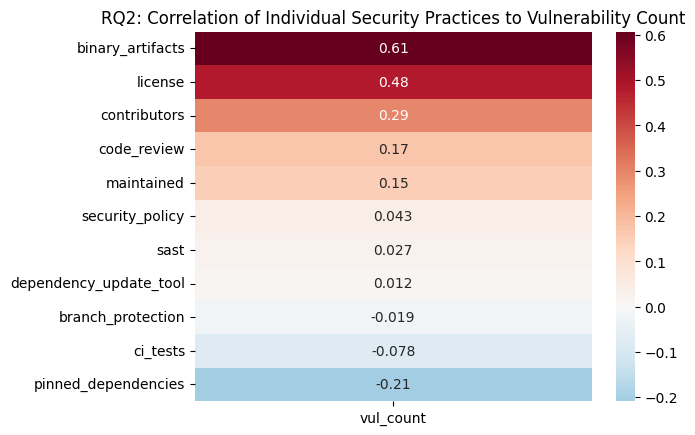

In [28]:
sns.heatmap(plot_data, annot=True, cmap='RdBu_r', center=0)
plt.title("RQ2: Correlation of Individual Security Practices to Vulnerability Count")
plt.show()

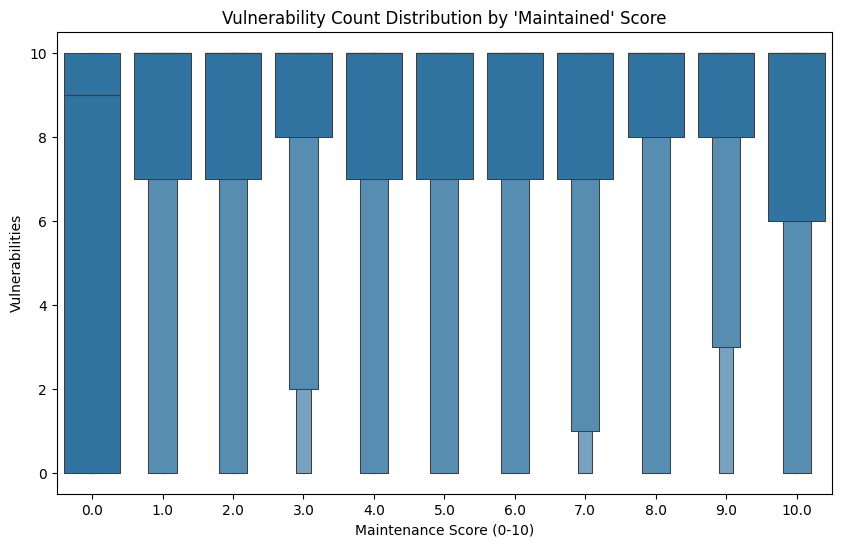

In [29]:
plt.figure(figsize=(10, 6))
sns.boxenplot(
    data=df_analysis.to_pandas(), 
    x='maintained', 
    y='vul_count'
)
plt.title("Vulnerability Count Distribution by 'Maintained' Score")
plt.xlabel("Maintenance Score (0-10)")
plt.ylabel("Vulnerabilities")
plt.show()

In [30]:
control_vars = ['package_total_downloads', 'github_repo_age_in_years']
df_regression = df.select(security_features + control_vars + [target]).with_columns([
    pl.col(c).cast(pl.Float64).fill_null(0) for c in (security_features + control_vars + [target])
])
pdf = df_regression.to_pandas()
X = pdf[security_features + control_vars]
y = pdf[target]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              vul_count   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     2928.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:08:46   Log-Likelihood:            -1.2355e+05
No. Observations:               46779   AIC:                         2.471e+05
Df Residuals:                   46765   BIC:                         2.473e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

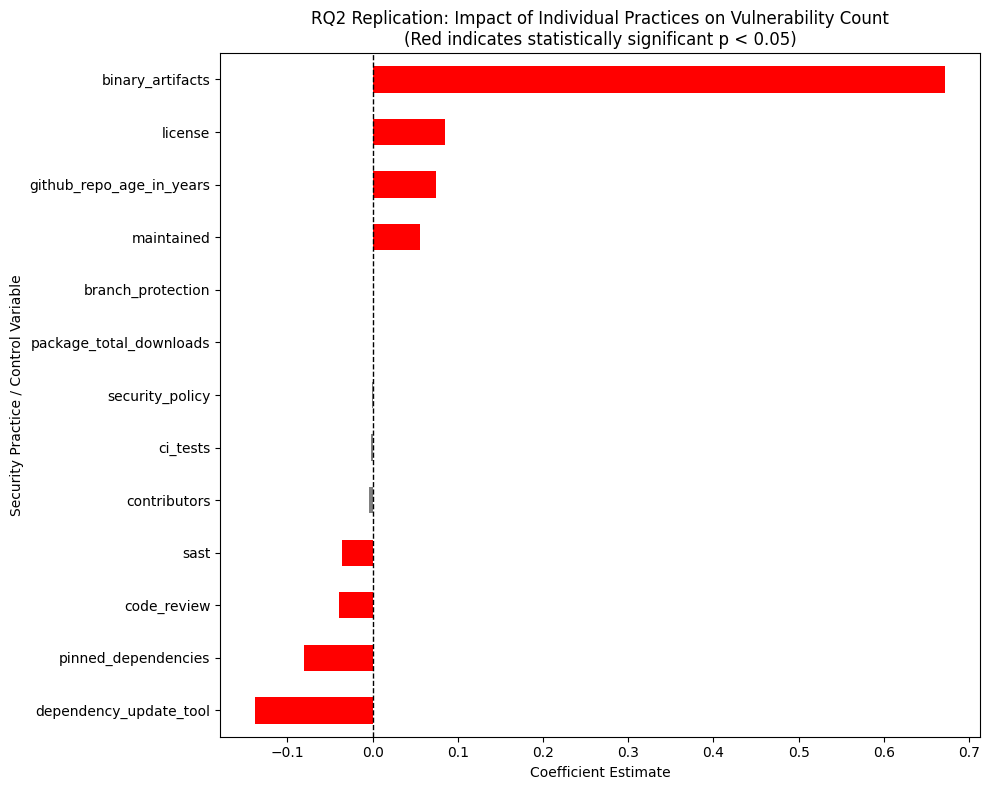

In [31]:
coeffs = model.params.drop('const').sort_values()
p_values = model.pvalues.drop('const')
plt.figure(figsize=(10, 8))
colors = ['red' if p < 0.05 else 'grey' for p in p_values[coeffs.index]]
coeffs.plot(kind='barh', color=colors)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title("RQ2 Replication: Impact of Individual Practices on Vulnerability Count\n(Red indicates statistically significant p < 0.05)")
plt.xlabel("Coefficient Estimate")
plt.ylabel("Security Practice / Control Variable")
plt.tight_layout()
plt.show()